# Set-Up

In [ ]:
# Install dependencies
!pip install -qU langchain-groq langgraph langchain-huggingface langchain-community faiss-cpu sentence-transformers > /dev/null 2>&1

#### Groq API Key
1. Go to https://console.groq.com/keys and create a new API key for use in this notebook.

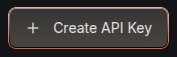

2. Add the API key to your Colab secrets under the name `GROQ_API_KEY`.

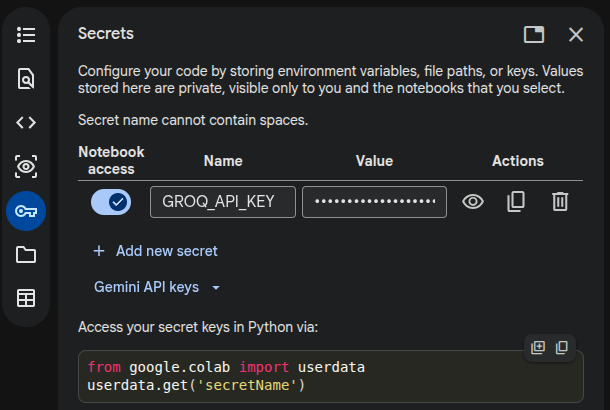


#### Imports

In [ ]:
# Standard Library & Infrastructure
import os
import logging
import operator
import warnings
from pprint import pprint
from textwrap import dedent as dd
from typing import Any, Annotated, Dict, List, Literal, TypedDict

# Google Colab & Environment Setup
from google.colab import userdata

# Set environment variables
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

# Suppress chatter
from transformers import logging as hf_logging
from langchain_core._api.deprecation import LangChainPendingDeprecationWarning

hf_logging.set_verbosity_error()
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=LangChainPendingDeprecationWarning)
warnings.filterwarnings(
    "ignore",
    message=".*unauthenticated requests to the HF Hub.*"
)

# LangChain & Hugging Face
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# LangGraph
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

#### Groq LLM ID

In [ ]:
GROQ_LLM_ID_SMALL = "llama-3.1-8b-instant"
GROQ_LLM_ID_BIG = "llama-3.3-70b-versatile"

In [ ]:
# "print" helpers
def p(*args) -> None:
    print(*args, end="\n"*2)

def pp(obj: Any) -> None:
    pprint(obj.__dict__ if hasattr(obj, "__dict__") else obj)
    print()

def ph(string: str) -> None:
    print(f"{'='*32}\n{string}\n{'-'*32}")

# Context

#### Problem

- An LLM is just a stateless function for predicting the next token.
- Information is baked in (new cannot be easily introduced).
- Very limited capacity to directly interact with the world.

#### What is LangChain?

LangChain is a framework for building applications powered by large language models, connecting them to tools, data, and workflows through structured chains. It works well for straightforward, mostly linear tasks.

#### What is LangGraph?

LangGraph builds on LangChain to support more complex workflows with loops, memory, and state. It is ideal for multi-agent systems or applications that need to retry, adapt, and continue until a goal is reached.

| &nbsp; | LangChain | LangGraph |
|:---|:---|:---|
| **Execution Flow** | Linear or Directed Acyclic Graph | Cyclic, looping, state machine |
| **Best For** | Predictable pipelines | Autonomous agents, multi-step reasoning, error correction |
| **State Management** | Data is passed step to step | Managed through a central State object |

# LangChain

#### Standard LangChain workflow:

1. **Prompt Template:** Formats raw user input into a structured prompt.
2. **LLM:** The brain that processes the prompt and generates a response.
3. **Output Parser:** Takes the output from the LLM and converts it into a usable Python object (like a string, dictionary, list, or Pydantic model).

With LangChain, information only flows toward the end of graph.

directed_acyclical_graph.svg

### Level 1

The Basic Pipe (Text-In, Text-Out)

langchain_level_1.svg

In [ ]:
# Prompt templates can be written like f-strings.
prompt = PromptTemplate.from_template(
    "Describe {prompt_variable} in 15 words or fewer."
)

llm = ChatGroq(
    # Model ID as listed by Groq.
    model=GROQ_LLM_ID_SMALL,
    # Inference temperature (0 for deterministic answers).
    temperature=0,
)

# A simple helper which extracts the "chat" part of an LLM response object.
parser = StrOutputParser()

# Langchain chains (RunnableSequence) are built with the pipe operator.
llm_response_object = prompt | llm
llm_response_with_parser = prompt | llm | parser


ph("PROMPT OBJECT")
p(prompt)

ph("LLM OBJECT")
p(llm)

"""
Execute chains by calling `invoke`. When you do so, pass as an argument a
dictionary that matches the template. Later, we'll see a different way input is
defined for the `invoke` method. Just know that it implicitly depends on the
beginning part or parts of your chain (in this case, the prompt object).

At the start of the chain, the prompt template introduces a free variable
named "prompt_variable", so our dictionary must contain the key
"prompt_variable", with an associated value that will be used to substitute in
for the free variable.
"""
ph("LLM RESPONSE OBJECT")
p(llm_response_object.invoke({"prompt_variable": "the taste of blue"}))

ph("LLM RESPONSE WITH PARSER")
p(llm_response_with_parser.invoke({"prompt_variable": "the taste of blue"}))

### Level 2

Structured Output

langchain_level_2.svg

In [ ]:
# Pydantic schema
class MyOutputSchema(BaseModel):
    poem: str
    self_assessment_score: float = Field(
        description="Poem quality from 0.0 to 10.0",
        ge=0.0,
        le=10.0,
    )


prompt = PromptTemplate.from_template(
    "Write a poem about {prompt_variable}."
)

llm = ChatGroq(
    model=GROQ_LLM_ID_SMALL,
    temperature=0,
)

chain = prompt | (llm.with_structured_output(MyOutputSchema))

result = chain.invoke({"prompt_variable": "Google Colab"})


ph("RESULT")
p(result)

"""
The resulting object is an instance of our MyOutputSchema Pydantic model. If the
llm fails to properly fill out the Pydantic schema, the chain will raise an
exception.
"""
print(type(result))

### Level 3

Parallel Execution / Diverging and Converging Graphs

langchain_level_3.svg

In [ ]:
def fake_RAG(question: str) -> str:
    docs = {
        "q3 earnings": dd("""
            Company Financial Report:
            - Q3 revenue was $12.4 million.
            - Net income increased 18%.
            - Operating margin was 14%.
        """)
    }

    q = question.lower()

    if "q3" in q and "earnings" in q:
        return docs["q3 earnings"]

    return "No relevant documents found."

prompt = PromptTemplate.from_template(dd("""
    Use the provided context to answer the question.

    Context:
    {context_variable}

    Question:
    {question_variable}

    Answer clearly and briefly.
    If the information is not available, state this as your answer.
"""))

llm = ChatGroq(
    model=GROQ_LLM_ID_SMALL,
    temperature=0
)

"""
By starting the chain with a dictionary, we create parallel execution paths.
For this chain, the input (question: str) is passed to each RunnableLambda and
RunnablePassthrough. Each entry in the dictionary defines a parallel path.

Here, RunnableLambda uses the `fake_RAG` function to define a node in our DAG.
RunnablePassthrough takes its input and passes it along without modification.

Because `fake_RAG` takes one string as input and RunnablePassthrough takes
anything as input, the input to the chain implicitly becomes exactly one string.

Note: like before, the dictionary's keys need to match the free variables in the
prompt. The results of those parallel nodes will be used to substitute in for
the free variables in the prompt.
"""
rag_chain = (
    {
        "context_variable": RunnableLambda(fake_RAG),
        "question_variable": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

question_1 = "For how long has the company existed?"
question_2 = "Can you give me a summary of the company's Q3 earnings?"

result_1 = rag_chain.invoke(question_1)
result_2 = rag_chain.invoke(question_2)

ph(question_1)
p(result_1)

ph(question_2)
p(result_2)

# LangGraph

#### Standard LangGraph workflow:
1. **State Schema:** Defines the shared structured state (often a dictionary or TypedDict) that stores information as the workflow runs.
2. **Nodes:** Individual steps (LLMs, tools, Python functions, retrievers, validators, etc.) that read from and update the state.
3. **Edges / Routing Logic:** Determines what node runs next, including conditional branches, loops, retries, or termination.

With LangGraph, information can flow forward, branch, merge, and loop back through the graph until a stopping condition is reached.

directed_cyclical_graph.svg

### Level 1

The Basic Graph (No loops, yet)

langgraph_level_1.svg

In [ ]:
class MyState(TypedDict):
    input_text: str
    output_text: str


"""
This function will be used to define what our `processor` node does.
Notice we only return a dictionary with the keys we wish to update.
"""
def process_text(state: MyState):
    return {"output_text": state["input_text"].upper()}

# Build and compile the graph.
graph = (
    StateGraph(MyState)
    .add_node("processor", process_text)
    .add_edge(START, "processor")
    .add_edge("processor", END)
    .compile()
)


"""
Similar to LangChain's chains, your graphs will usually be invoked by passing
a dictionary-like object as an argument.

The passed dictionary should be composed of some sufficient subset of the
graph-state items. For example, we could pass
`{"input_text": "abc", "output_text": "123"}`, and the graph execution would
overwite the output_text value. If we try to pass an empty dictionary, an error
is thrown because our `process_text` function expects there to be a string value
under that key.
"""
input_state = {"input_text": "Hello, World!"}

ph("INPUT STATE")
p(input_state)

ph("OUTPUT STATE")
p(graph.invoke(input_state))

### Level 2

Loops with the Collatz Conjecture

langgraph_level_2.svg

In [ ]:
# @title
class CollatzState(TypedDict):
    n: int
    steps: int
    history: list[int]

def halve(state: CollatzState):
    n = state["n"] // 2

    return {
        "n": n,
        "steps": state["steps"] + 1,
        "history": state["history"] + [n]
    }


def triple_plus_one(state: CollatzState):
    n = state["n"] * 3 + 1

    return {
        "n": n,
        "steps": state["steps"] + 1,
        "history": state["history"] + [n]
    }

def route_collatz(state: CollatzState):
    n = state["n"]

    if n == 1:
        return END
    elif n % 2 == 0:
        return "0.5n node"
    else:
        return "3n+1 node"

graph = (
    StateGraph(CollatzState)
    .add_node("0.5n node", halve)
    .add_node("3n+1 node", triple_plus_one)
    .add_conditional_edges(
        START,
        route_collatz
    )
    .add_conditional_edges(
        "0.5n node",
        route_collatz
    )
    .add_conditional_edges(
        "3n+1 node",
        route_collatz
    )
    .compile()
)

initial_number: int = 67

result = graph.invoke({
    "n": initial_number,
    "steps": 0,
    "history": [initial_number]
})

ph(f"RESULTS FOR {initial_number}")
p(result)

### Level 3

Human-in-the-Loop, config, and memory

langgraph_level_3.svg

In [ ]:
class AgentState(TypedDict):
    user_request: str
    sql_query: str
    execution_result: str


# Mock an LLM drafting a SQL query.
def draft_query(state: AgentState):
    p("AGENT: Drafting SQL query...")
    user_req = state["user_request"]
    return {
        "sql_query": f"SELECT * FROM users WHERE intent = '{user_req}';"
    }

# Mock executing a potentially dangerous action (running an LLM's SQL query).
def execute_query(state: AgentState):
    p(f"SYSTEM: Executing SQL: {state["sql_query"]}")
    return {"execution_result": "Query executed successfully. 5 rows returned."}


graph = (
    StateGraph(AgentState)
    .add_node("drafter", draft_query)
    .add_node("executor", execute_query)
    .add_edge(START, "drafter")
    .add_edge("drafter", "executor")
    .add_edge("executor", END)
    .compile(
        # Where and how to save the in-progress execution graph.
        checkpointer=MemorySaver(),
        # Pause execution of the graph upon reaching the the `executor` node.
        # Alternatively, one could use `iterrupt_after=["drafter"]`.
        interrupt_before=["executor"]
    )
)


ph("AGENT DRAFTS QUERY")
config = {"configurable": {"thread_id": "sql_query_review_1"}}
graph.invoke({"user_request": "churned_last_30_days"}, config=config)


ph("HUMAN REVIEWS")

p(f"Drafted SQL: {graph.get_state(config).values["sql_query"]}")
user_input = (
    input("Press Enter to approve, or type a SQL query to override:\n> ")
    .strip()
)

if user_input:
    # Update the query with the manual correction.
    graph.update_state(
        config,
        {"sql_query": user_input}
    )
    p("Query updated.")
else:
    p("Query approved.")


ph("GRAPH EXECUTION RESUMES")
# Passing `None` as the input tells the graph to resume from where it paused.
final_state = graph.invoke(None, config=config)


ph("FINAL RESULT")
p(final_state["execution_result"])

# Draw the Circle

US State Guessing Game

guessing_game.svg

In [ ]:
NUM_QUESTIONS = 8

class GameState(TypedDict):
    turn: int
    history: str
    status: Literal["asking", "done"]
    message: str


ask_prompt = PromptTemplate.from_template(dd("""
    You are playing a game where the user is thinking of a specific U.S. state.

    Conversation so far:
    {history}

    Ask ONE short yes/no question that helps identify the state.
    Do your best to narrow down the possibilities with your question.
    Do not guess yet.
    Only output the question.
"""))

guess_prompt = PromptTemplate.from_template(dd("""
    You are playing a game where the user is thinking of one U.S. state.

    Conversation so far:
    {history}

    Based on the answers, make your best final guess.

    Only output:
    Is it <state name>?
"""))

llm = ChatGroq(
    model=GROQ_LLM_ID_BIG,
    temperature=0.5
)

parser = StrOutputParser()

ask_chain = ask_prompt | llm | parser
guess_chain = guess_prompt | llm | parser


def ask_question(state: GameState):
    return {
        "message": ask_chain.invoke({"history": state["history"]}),
        "status": "asking",
    }


def make_guess(state: GameState):
    return {
        "message": guess_chain.invoke({"history": state["history"]}),
        "status": "done",
    }


def route(state: GameState):
    if state["turn"] >= NUM_QUESTIONS:
        return "guess"

    return "ask"


graph = (
    StateGraph(GameState)
    .add_node("ask", ask_question)
    .add_node("guess", make_guess)
    .add_conditional_edges(START, route)
    .add_edge("ask", END)
    .add_edge("guess", END)
    .compile()
)



state = {
    "turn": 0,
    "history": "",
    "status": "asking",
    "message": (
        "Think of a U.S. state.\n"
        f"I will ask {NUM_QUESTIONS} yes/no questions "
        "and then try to guess the state."
    )
}

ph("BEGIN GAME")

print(state["message"])

while state["status"] != "done":

    """
    In this example, the whole graph is executed multiple times. The looping is
    done with the while loop to keep the side-effect of `input` out of the
    graph.
    """
    state = graph.invoke(state)

    print("\nLLM:", state["message"])

    if state["status"] == "done":
        break

    answer = input("You (yes/no): ").strip().lower()

    state["history"] += (
        f"\nQ{state["turn"] + 1}: {state["message"]}"
        f"\nA{state["turn"] + 1}: {answer}"
    )

    state["turn"] += 1

# Draw the Rest of the Owl

Medical Exam Grader

medical_exam_grader.svg

In [ ]:
# Mock medical corpus
medical_corpus = [
    "Type 1 Diabetes Mellitus is characterized by the autoimmune destruction of pancreatic beta cells.",
    "This autoimmune attack leads to an absolute deficiency of insulin.",
    "Without insulin, glucose cannot enter cells, leading to hyperglycemia.",
    "Streptococcus pneumoniae is the most common bacterial cause of community-acquired pneumonia."
]

# Mock exam data
exam_submission = {
    "student_name": "Dr. Jane Doe",
    "questions": [
        {
            "id": "Q1",
            "type": "multiple_choice",
            "question": "Which of the following is the most common cause of community-acquired pneumonia?",
            "student_answer": "B",
            "correct_answer": "B",
        },
        {
            "id": "Q2",
            "type": "open_ended",
            "question": "Explain the underlying pathophysiology of Type 1 Diabetes Mellitus.",
            "student_answer": "It's an autoimmune condition where the body's immune system attacks and destroys the insulin-producing beta cells in the pancreas. This leads to an absolute deficiency of insulin, causing high blood glucose levels.",
            "professor_expectation": "Students must explicitly mention 'autoimmune destruction', 'beta cells', and 'absolute insulin deficiency'. Deduct 0.3 points for each missing concept. Do not penalize for spelling errors."
        }
    ]
}



# RAG
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = FAISS.from_texts(
    medical_corpus,
    embedding=HuggingFaceEmbeddings(
        model_name="all-MiniLM-L6-v2",
        model_kwargs={'device': 'cpu'}
    )
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})


class ExamState(TypedDict):
    student_name: str
    questions: List[Dict]
    current_index: int
    results: Annotated[List[Dict], operator.add]
    final_report: str
    retrieved_context: str

class GradingResult(BaseModel):
    score: float = Field(
        description="Score from 0.0 to 1.0 based strictly on the rubric.",
        ge=0.0,
        le=1.0,
    )
    feedback: str = Field(description=(
        "Medical feedback explaining the score and any missing concepts."
    ))


def multiple_choice_grader_node(state: ExamState):
    """Grades Multiple Choice Questions using pure Python (Fast & Free)."""
    current_question = state["questions"][state["current_index"]]

    student_answer = (
        current_question["student_answer"]
        .strip()
        .upper()
    )

    correct_answer = (
        current_question["correct_answer"]
        .strip()
        .upper()
    )

    is_correct = student_answer == correct_answer
    score = 1.0 if is_correct else 0.0
    feedback = (
        "Correct." if is_correct
        else (
            "Incorrect. The correct answer was "
            f"{current_question["correct_answer"]}."
        )
    )

    result = {
        "id": current_question["id"],
        "type": "multiple_choice",
        "score": score,
        "feedback": feedback
    }
    return {
        "current_index": state["current_index"] + 1,
        "results": [result],
        "retrieved_context": ""
    }

def retrieve_context_node(state: ExamState):
    current_question = state["questions"][state["current_index"]]

    docs = retriever.invoke(current_question["question"])
    context = "\n".join(doc.page_content for doc in docs)
    return {"retrieved_context": context}

def open_ended_grader_node(state: ExamState):
    current_question = state["questions"][state["current_index"]]
    llm = (
        ChatGroq(
            model=GROQ_LLM_ID_BIG,
            temperature=0.0
        )
        .with_structured_output(GradingResult)
    )

    prompt = ChatPromptTemplate.from_template("""
    You are a strict but fair medical grading assistant.

    Question: {question}
    Student's Answer: {answer}

    ---
    TEXTBOOK CONTEXT (Ground Truth):
    {context}

    ---
    PROFESSOR'S GRADING RUBRIC:
    {rubric}
    ---

    Evaluate the student's answer using ONLY the textbook context provided.
    Calculate the final score based STRICTLY on the Professor's Grading Rubric.
    """)

    chain = prompt | llm
    eval_data = chain.invoke({
        "question": current_question["question"],
        "answer": current_question["student_answer"],
        "context": state["retrieved_context"],
        "rubric": current_question["professor_expectation"]
    })

    result = {
        "id": current_question["id"],
        "type": "open_ended",
        "score": eval_data.score,
        "feedback": eval_data.feedback
    }
    return {
        "current_index": state["current_index"] + 1,
        "results": [result],
        "retrieved_context": ""
    }

def report_generator_node(state: ExamState):
    """Compiles the final grades."""
    total_score = sum(r["score"] for r in state["results"])
    max_score = len(state["questions"])
    percentage = (total_score / max_score) * 100
    student_name = state["student_name"].upper()

    report = f"==== FINAL GRADE REPORT FOR {student_name} ====\n"
    report += f"Final Score: {total_score}/{max_score} ({percentage:.1f}%)\n\n"
    for r in state["results"]:
        report += (
            f"Question {r["id"]}: {r["score"]}/1.0\n"
            f"Feedback: {r["feedback"]}\n\n"
        )

    return {"final_report": report}

def router(state: ExamState):
    if state["current_index"] >= len(state["questions"]):
        return "report_generator"

    current_question_type = state["questions"][state["current_index"]]["type"]
    return (
        "multiple_choice_grader" if current_question_type == "multiple_choice"
        else "retrieve_context"
    )


graph = (
    StateGraph(ExamState)

    .add_node("multiple_choice_grader", multiple_choice_grader_node)
    .add_node("retrieve_context", retrieve_context_node)
    .add_node("open_ended_grader", open_ended_grader_node)
    .add_node("report_generator", report_generator_node)

    .add_edge("retrieve_context", "open_ended_grader")
    .add_edge("report_generator", END)

    .add_conditional_edges(START, router)
    .add_conditional_edges("multiple_choice_grader", router)
    .add_conditional_edges("open_ended_grader", router)

    .compile()
)


final_state = graph.invoke({
    "student_name": exam_submission["student_name"],
    "questions": exam_submission["questions"],
    "current_index": 0,
    "results": [],
    "final_report": "",
    "retrieved_context": ""
})
p(final_state["final_report"])